### RaschPy matrix MFRM worked example

This notebook works through a sample Rasch analysis of a simulated data set (200 persons, 8 items with a maximum score of 5, all rated by 8 raters, no missing data), taking you through the relevant commands step by step, with notes before each cell. Relevant outputs will appear below each cell.

Under the matrix parameterisation, each rater has a full, independent severity for every item x threshold combination — the most flexible (and most heavily parameterised) of the five rater representations.

Import the modules and set the working directory (here called `my_working_directory`) to where you want to save your output files.

In [1]:
import raschpy as rp
import pandas as pd
import os

os.chdir('my_working_directory')

**A note on data validation**

Every model constructor validates the item-response network automatically at instantiation (`validate=True` by default) and warns if it's disconnected — if there's no chain of persons and items linking every item to every other, the resulting item locations aren't on a common scale, even though `calibrate()` will still run without error. This is worth seeing happen once. Here we build a small, deliberately disconnected data set: two groups of persons who each only answer a disjoint set of items, with no item shared between the groups to link them:

In [2]:
sim_disconnected = rp.MFRM_Sim_Matrix(no_of_items=8, no_of_persons=40, no_of_facet_elements=4, max_score=5, seed=99)
responses_disconnected = sim_disconnected.responses.copy()
persons = responses_disconnected.index.get_level_values(1).unique()
group_a, group_b = persons[:20], persons[20:]
responses_disconnected.loc[(slice(None), group_a), responses_disconnected.columns[4:]] = float('nan')   # group A: only items 1-4
responses_disconnected.loc[(slice(None), group_b), responses_disconnected.columns[:4]] = float('nan')    # group B: only items 5-8

broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning

/Users/markelliott/Documents/GitHub/RaschPy/raschpy/mfrm.py:476: UserWarning: The data is split into 2 disconnected sub-networks. This will break un-smoothed calibrations. Isolated groupings: Sub-group 1 (size 4): ['Item_1', 'Item_2', 'Item_3', 'Item_4']; Sub-group 2 (size 4): ['Item_5', 'Item_6', 'Item_7', 'Item_8']
  self.connectivity_status = self.check_data_connectivity()
/var/folders/hs/f4mv8_3d65bf5fln8jlxhxpc0000gn/T/ipykernel_96989/1060609686.py:8: UserWarning: 
⚠️  CRITICAL DATA INTEGRITY WARNING: The response data is disconnected into 2 separate sub-networks.
Item location estimates will be problematic because there are no empirical comparisons spanning across these isolated groups, the item parameter estimates for each independent subset will separately sum to zero. This means items belonging to different subsets cannot be compared or calibrated onto a single scale.
  broken_mfrm = rp.MFRM(responses_disconnected)   # raises a UserWarning


`connectivity_status` records the diagnosis, including which items ended up in which isolated sub-group:

In [3]:
broken_mfrm.connectivity_status

{'connected': False,
 'components_count': 2,
 'isolated_items': [],
 'all_sub_groups': [['Item_1', 'Item_2', 'Item_3', 'Item_4'],
  ['Item_5', 'Item_6', 'Item_7', 'Item_8']],
 'directionally_isolated_items': [],
 'strongly_connected': False}

The rest of this notebook uses a single, fully-connected simulated data set, so this warning won't come up again.

Simulate a data set. Passing `seed=999` makes the simulation fully reproducible — rerunning this notebook will always generate the same data set. 12 items, 8 raters, 200 persons, no missing data.

In [4]:
sim = rp.MFRM_Sim_Matrix(no_of_items=12, no_of_persons=200, no_of_facet_elements=8, max_score=5, missing=0, seed=999)
sim.responses.to_csv('mfrm_matrix_scores.csv')

If you have your own response data saved to a CSV file instead of simulating it, use `loadup_mfrm_single()` to load and validate it. Demonstrated here by reloading the file we just saved:

In [5]:
data, invalid_responses = rp.loadup_mfrm_single('mfrm_matrix_scores.csv', max_score=5)

Check the data - view the first two lines

In [6]:
data.head(2)

Item_1  Item_2  Item_3  Item_4  Item_5  Item_6  Item_7  \
Rater   Person                                                             
Rater_1 Person_1     3.0     3.0     4.0     3.0     3.0     3.0     3.0   
        Person_2     2.0     2.0     2.0     2.0     3.0     1.0     2.0   

                  Item_8  Item_9  Item_10  Item_11  Item_12  
Rater   Person                                               
Rater_1 Person_1     4.0     3.0      3.0      3.0      3.0  
        Person_2     3.0     1.0      3.0      3.0      2.0

Check for any invalid responses (not usable for estimation purposes and excluded)

In [7]:
invalid_responses

,,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater,Person,,,,,,,,,,,,


Create an MFRM object. Passing the simulation object `sim` directly (rather than the reloaded `data`) attaches the generating parameters under `mfrm.generating`, which lets us check parameter recovery further down. If you're analysing your own data, pass a DataFrame instead (e.g. `rp.MFRM(data)`).

In [8]:
mfrm = rp.MFRM(sim)

Calibrate under the matrix parameterisation (a full, independent severity per rater x item x threshold combination). The `%%time` "magic function" returns the time taken to run the cell contents (algorithm run time in this case).

In [9]:
%%time
mfrm.calibrate_matrix()

CPU times: user 6.92 ms, sys: 609 μs, total: 7.53 ms
Wall time: 7.2 ms


Check the item location estimates - view the first two items

In [10]:
mfrm.items.head(2)

Item_1    0.953710
Item_2    0.325097
dtype: float64

Since this is simulated data, we know the true generating item locations (mfrm.generating.items) and can check how closely the calibration recovered them. The helper below plots generating vs. estimated values, with an identity line (dashed dark red) and a fitted regression line (dashed red) — the closer the points hug the identity line, the better the recovery. Also displays the Pearson correlation, SD ratio, regression coefficient and RMSE. Recovery for the rater severities will be noisier than the other parameterisations (see below), since the matrix model spreads the same amount of data across many more free parameters (a severity for every rater x item x threshold cell):

In [11]:
import numpy as np
from matplotlib import pyplot as plt

def recovery_plot(generating, estimated, label, filename):
    x, y = np.asarray(generating), np.asarray(estimated)
    fig, ax = plt.subplots()
    ax.scatter(x, y, alpha=0.6)
    lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
    ax.plot([lo, hi], [lo, hi], color='DarkRed', label='Identity')
    m, b = np.polyfit(x, y, 1)
    ax.plot([lo, hi], [m * lo + b, m * hi + b], color='Red', linestyle='--', label='Regression')
    ax.set_xlabel(f'Generating {label}')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_aspect('equal')
    ax.legend()
    plt.savefig(filename)
    plt.show()
    print(f'{label} Pearson correlation:               {round(np.corrcoef(x, y)[0, 1], 3)}')
    print(f'{label} SD ratio (estimated / generating): {round(y.std() / x.std(), 3)}')
    print(f'{label} regression coefficient:            {round(m, 3)}')
    print(f'{label} RMSE:                              {round(np.sqrt(((x - y) ** 2).mean()), 3)}')


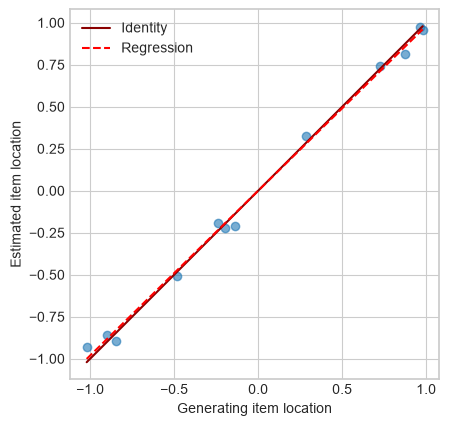

item location Pearson correlation:               0.998
item location SD ratio (estimated / generating): 0.983
item location regression coefficient:            0.981
item location RMSE:                              0.047


In [12]:
recovery_plot(mfrm.generating.items, mfrm.items, 'item location', 'my_mfrm_matrix_item_recovery.png')

Generate a table of item statistics (and check run time), and save to file

In [13]:
%%time
mfrm.item_stats_df_matrix(full=True)
mfrm.item_stats_matrix.to_csv('mfrm_matrix_item_stats.csv')

CPU times: user 5.98 s, sys: 85 ms, total: 6.06 s
Wall time: 6.06 s


Check the item statistics table

In [14]:
mfrm.item_stats_matrix

,Estimate,SE,2.5%,97.5%,Count,Facility,Infit MS,Infit Z,Outfit MS,Outfit Z,PM corr,Exp PM corr
Item_1,0.954,0.047,0.862,1.040,1600,0.432,0.956,-1.262,0.957,-1.227,0.680,0.671
Item_2,0.325,0.042,0.243,0.410,1600,0.494,0.902,-2.853,0.886,-3.355,0.689,0.668
Item_3,-0.507,0.043,-0.588,-0.422,1600,0.572,0.968,-0.902,0.996,-0.103,0.649,0.643
Item_4,0.745,0.046,0.661,0.836,1600,0.459,0.960,-1.140,0.937,-1.822,0.690,0.674
Item_5,0.974,0.043,0.892,1.054,1600,0.431,0.948,-1.482,0.936,-1.843,0.696,0.668
Item_6,-0.210,0.039,-0.288,-0.139,1600,0.546,0.900,-2.925,0.905,-2.764,0.668,0.654
Item_7,-0.219,0.042,-0.298,-0.135,1600,0.546,0.948,-1.473,0.922,-2.248,0.662,0.655
Item_8,-0.931,0.043,-1.018,-0.843,1600,0.607,0.951,-1.391,0.949,-1.465,0.628,0.632
Item_9,-0.892,0.045,-0.979,-0.807,1600,0.600,0.937,-1.809,0.918,-2.375,0.644,0.625
Item_10,-0.194,0.037,-0.260,-0.119,1600,0.544,0.924,-2.207,0.920,-2.311,0.673,0.656


Generate a table of threshold statistics (and check run time), and save to file

In [15]:
%%time
mfrm.threshold_stats_df_matrix(full=True)
mfrm.threshold_stats_matrix.to_csv('mfrm_matrix_threshold_stats.csv')

CPU times: user 114 ms, sys: 2.4 ms, total: 116 ms
Wall time: 116 ms


Check the threshold statistics table

In [16]:
mfrm.threshold_stats_matrix

,Estimate,SE,2.5%,97.5%,Infit MS,Infit Z,Outfit MS,Outfit Z,Discrim,PM corr,Exp PM corr
Threshold 1,-4.196,0.089,-4.303,-3.955,0.908,-2.648,0.893,-1.236,1.072,0.367,0.373
Threshold 2,-1.439,0.049,-1.534,-1.341,0.966,-2.805,0.955,-2.176,1.078,0.756,0.700
Threshold 3,-1.108,0.035,-1.179,-1.039,0.981,-1.757,0.965,-1.708,1.033,0.890,0.862
Threshold 4,2.384,0.041,2.290,2.450,0.949,-3.766,0.897,-3.727,1.065,0.757,0.721
Threshold 5,4.359,0.085,4.143,4.478,0.851,-3.115,0.885,-0.997,1.095,0.188,0.211


And the same recovery check for thresholds, against `mfrm.generating.thresholds`:

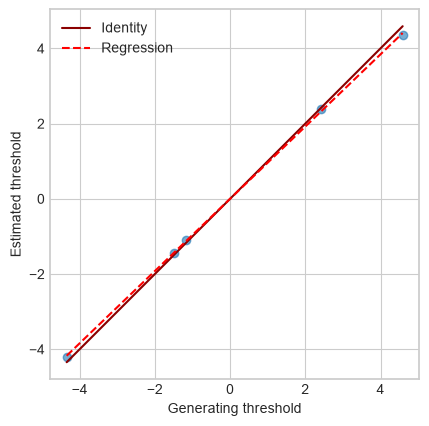

threshold Pearson correlation:               1.0
threshold SD ratio (estimated / generating): 0.96
threshold regression coefficient:            0.96
threshold RMSE:                              0.13


In [17]:
recovery_plot(mfrm.generating.thresholds, mfrm.thresholds, 'threshold', 'my_mfrm_matrix_threshold_recovery.png')

Generate a table of rater statistics (and check run time), and save to file. By default (`marginal=True`) this reports one row per rater, with item and threshold marginal severities. Pass `marginal=False` for the full (item, threshold) cell-level table instead.

In [18]:
%%time
mfrm.rater_stats_df_matrix()
mfrm.rater_stats_matrix.to_csv('mfrm_matrix_rater_stats.csv')

CPU times: user 61.7 ms, sys: 926 μs, total: 62.7 ms
Wall time: 62.7 ms


Check the rater statistics table

In [19]:
mfrm.rater_stats_matrix

Item_1          Item_2          Item_3          Item_4         \
        Estimate     SE Estimate     SE Estimate     SE Estimate     SE   
Rater_1    0.182  0.111   -0.110  0.147   -0.217  0.148   -0.308  0.154   
Rater_2    0.372  0.129    0.104  0.168   -0.400  0.240    0.143  0.120   
Rater_3   -0.299  0.166   -0.349  0.129   -0.023  0.248   -0.426  0.205   
Rater_4   -0.080  0.132    0.176  0.118    0.006  0.242   -0.149  0.211   
Rater_5    0.162  0.146    0.199  0.146    0.543  0.168    0.210  0.119   
Rater_6   -0.649  0.150   -0.154  0.183    0.061  0.197    0.026  0.164   
Rater_7    0.330  0.126    0.383  0.130   -0.195  0.238    0.237  0.142   
Rater_8   -0.019  0.120   -0.249  0.157    0.226  0.202    0.267  0.127   

          Item_5         ... Threshold 2 Threshold 3        Threshold 4  \
        Estimate     SE  ...          SE    Estimate     SE    Estimate   
Rater_1   -0.058  0.123  ...       0.090       0.152  0.060       0.097   
Rater_2    0.360  0.118  ...       0.096      -0.140  0.059      -0.008   
Rater_3    0.044  0.115  ...       0.101       0.046  0.064      -0.041   
Rater_4    0.207  0.121  ...       0.103      -0.059  0.053       0.154   
Rater_5   -0.309  0.150  ...       0.094      -0.188  0.062      -0.065   
Rater_6   -0.020  0.130  ...       0.094       0.064  0.070       0.114   
Rater_7   -0.224  0.138  ...       0.104       0.034  0.063      -0.072   
Rater_8   -0.001  0.148  ...       0.099       0.091  0.069      -0.179   

               Threshold 5        Overall statistics                     
            SE    Estimate     SE              Count Infit MS Outfit MS  
Rater_1  0.080      -0.164  0.118             2400.0    0.916     0.900  
Rater_2  0.088       0.150  0.142             2400.0    0.948     0.941  
Rater_3  0.092      -0.087  0.136             2400.0    0.958     0.965  
Rater_4  0.086      -0.337  0.147             2400.0    0.924     0.939  
Rater_5  0.075      -0.057  0.122             2400.0    0.986     0.970  
Rater_6  0.076      -0.077  0.112             2400.0    0.925     0.921  
Rater_7  0.089       0.158  0.151             2400.0    0.912     0.901  
Rater_8  0.091       0.413  0.127             2400.0    0.960     0.939  

[8 rows x 37 columns]

And the same recovery check for the full rater x item x threshold severities, against `mfrm.generating.facet_effects`. Since these are per rater x item x threshold, we flatten with `.stack()` first — expect this to be the noisiest of the recovery plots, for the reason noted above:

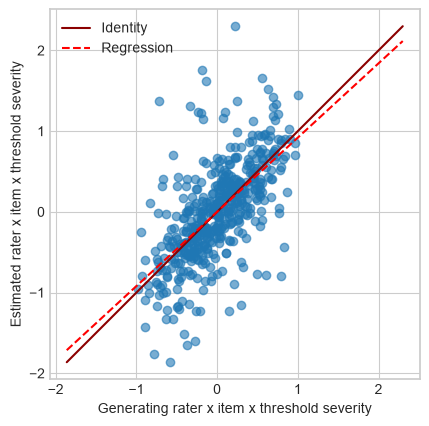

rater x item x threshold severity Pearson correlation:               0.632
rater x item x threshold severity SD ratio (estimated / generating): 1.456
rater x item x threshold severity regression coefficient:            0.92
rater x item x threshold severity RMSE:                              0.471


In [20]:
orig_severities = mfrm.generating.facet_effects.stack()
est_severities = mfrm.raters_matrix.stack()
recovery_plot(orig_severities, est_severities, 'rater x item x threshold severity', 'my_mfrm_matrix_rater_recovery.png')

Generate a table of person statistics (and check run time), and save to file

In [21]:
%%time
mfrm.person_stats_df_matrix(full=True)
mfrm.person_stats_matrix.to_csv('mfrm_matrix_person_stats.csv')

CPU times: user 20.7 ms, sys: 1.03 ms, total: 21.8 ms
Wall time: 21.6 ms


Check the person statistics table - view the first ten persons with `.head(10)`

In [22]:
mfrm.person_stats_matrix.head(10)

,Estimate,CSEM,RSEM,Score,Max score,p,Infit MS,Outfit MS,Infit Z,Outfit Z
Person_1,0.994,0.168,0.141,296,480,0.617,0.703,0.696,-1.788,-1.776
Person_2,-0.618,0.137,0.125,226,480,0.471,0.837,0.905,-1.197,-0.578
Person_3,-2.803,0.148,0.134,105,480,0.219,0.821,0.870,-1.201,-0.796
Person_4,0.096,0.151,0.152,261,480,0.544,1.013,0.938,0.137,-0.297
Person_5,0.637,0.162,0.168,283,480,0.590,1.071,1.126,0.452,0.713
Person_6,-0.710,0.135,0.141,221,480,0.460,1.083,1.104,0.632,0.710
Person_7,-0.408,0.140,0.114,237,480,0.494,0.658,0.651,-2.671,-2.402
Person_8,-0.995,0.132,0.114,205,480,0.427,0.737,0.747,-2.125,-1.892
Person_9,0.380,0.157,0.156,273,480,0.569,0.986,0.925,-0.024,-0.359
Person_10,-1.782,0.131,0.123,159,480,0.331,0.870,0.820,-0.994,-1.313


And the same recovery check for person locations, against `mfrm.generating.persons`:

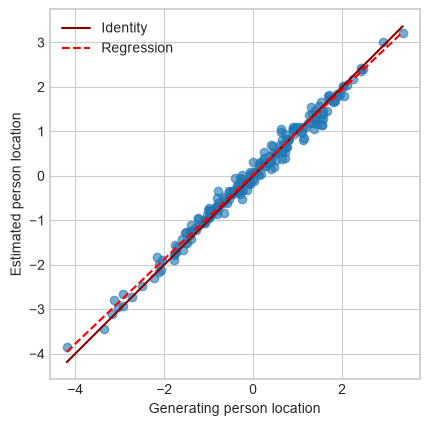

person location Pearson correlation:               0.994
person location SD ratio (estimated / generating): 0.958
person location regression coefficient:            0.952
person location RMSE:                              0.161


In [23]:
recovery_plot(mfrm.generating.persons, mfrm.persons_matrix, 'person location', 'my_mfrm_matrix_person_recovery.png')

Generate a table of test-level statistics (and check run time), and save to file

In [24]:
%%time
mfrm.test_stats_df_matrix()
mfrm.test_stats_matrix.to_csv('mfrm_matrix_test_stats.csv')

CPU times: user 4.06 ms, sys: 788 μs, total: 4.85 ms
Wall time: 4.64 ms


Check the test statistics table

In [25]:
mfrm.test_stats_matrix

,Items,Persons
Mean,0.000,0.031
SD,0.736,1.276
Separation ratio,17.305,8.612
Strata,23.406,11.816
Reliability,0.997,0.987


Run an item residual correlation analysis (and check run time), and save relevant output to file

In [26]:
%%time
mfrm.item_res_corr_analysis_matrix()
mfrm.item_residual_correlations_matrix.to_csv('mfrm_matrix_item_residual_correlations.csv')
mfrm.item_loadings_matrix.to_csv('mfrm_matrix_item_loadings.csv')

CPU times: user 8.4 ms, sys: 2.8 ms, total: 11.2 ms
Wall time: 15.6 ms


View the table of pairwise standard residual correlations (pairwise local item independence check)

In [27]:
round(mfrm.item_residual_correlations_matrix, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Item_1,1.000,-0.050,-0.012,-0.025,-0.011,-0.029,-0.025,-0.011,-0.041,-0.027,0.040,-0.050
Item_2,-0.050,1.000,-0.031,0.035,-0.025,-0.006,-0.015,-0.012,-0.020,-0.005,0.016,0.009
Item_3,-0.012,-0.031,1.000,-0.019,-0.009,-0.008,0.038,-0.009,-0.013,0.018,-0.017,-0.011
Item_4,-0.025,0.035,-0.019,1.000,0.018,-0.059,0.019,-0.004,-0.042,-0.037,-0.022,-0.007
Item_5,-0.011,-0.025,-0.009,0.018,1.000,0.040,-0.045,-0.023,0.006,0.007,0.003,0.025
Item_6,-0.029,-0.006,-0.008,-0.059,0.040,1.000,0.003,-0.026,-0.001,-0.033,-0.003,-0.033
Item_7,-0.025,-0.015,0.038,0.019,-0.045,0.003,1.000,0.006,-0.015,-0.013,-0.030,0.013
Item_8,-0.011,-0.012,-0.009,-0.004,-0.023,-0.026,0.006,1.000,-0.020,-0.033,0.010,-0.049
Item_9,-0.041,-0.020,-0.013,-0.042,0.006,-0.001,-0.015,-0.020,1.000,-0.036,0.011,-0.041
Item_10,-0.027,-0.005,0.018,-0.037,0.007,-0.033,-0.013,-0.033,-0.036,1.000,0.023,-0.021


View the item loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [28]:
round(mfrm.item_loadings_matrix['PC 1'], 3)

Item_1    -0.134
Item_2     0.105
Item_3     0.012
Item_4     0.158
Item_5    -0.036
Item_6    -0.083
Item_7     0.107
Item_8    -0.018
Item_9    -0.089
Item_10   -0.028
Item_11   -0.118
Item_12    0.132
Name: PC 1, dtype: float64

Run a rater residual correlation analysis (and check run time), and save relevant output to file

In [29]:
%%time
mfrm.rater_res_corr_analysis_matrix()
mfrm.rater_residual_correlations_matrix.to_csv('mfrm_matrix_rater_residual_correlations.csv')
mfrm.rater_loadings_matrix.to_csv('mfrm_matrix_rater_loadings.csv')

CPU times: user 14 ms, sys: 662 μs, total: 14.7 ms
Wall time: 14.9 ms


View the table of pairwise standard residual correlations (pairwise local rater independence check)

In [30]:
round(mfrm.rater_residual_correlations_matrix, 3)

,Rater_1,Rater_2,Rater_3,Rater_4,Rater_5,Rater_6,Rater_7,Rater_8
Rater_1,1.000,0.023,0.010,0.022,-0.004,-0.007,0.005,-0.006
Rater_2,0.023,1.000,-0.013,-0.004,-0.013,-0.024,-0.021,-0.024
Rater_3,0.010,-0.013,1.000,-0.018,0.003,-0.072,-0.003,-0.034
Rater_4,0.022,-0.004,-0.018,1.000,-0.016,-0.019,-0.000,-0.030
Rater_5,-0.004,-0.013,0.003,-0.016,1.000,-0.002,0.015,-0.024
Rater_6,-0.007,-0.024,-0.072,-0.019,-0.002,1.000,-0.047,-0.022
Rater_7,0.005,-0.021,-0.003,-0.000,0.015,-0.047,1.000,-0.012
Rater_8,-0.006,-0.024,-0.034,-0.030,-0.024,-0.022,-0.012,1.000


View the rater loadings on the first principal component of the pairwise standard residual correlations (dimensionality test)

In [31]:
round(mfrm.rater_loadings_matrix['PC 1'], 3)

Rater_1   -0.014
Rater_2    0.059
Rater_3   -0.240
Rater_4   -0.024
Rater_5   -0.030
Rater_6    0.283
Rater_7   -0.133
Rater_8    0.074
Name: PC 1, dtype: float64

Produce an item characteristic curve (item response function) curve for Item 2, with observed category means plotted and the central item location marked

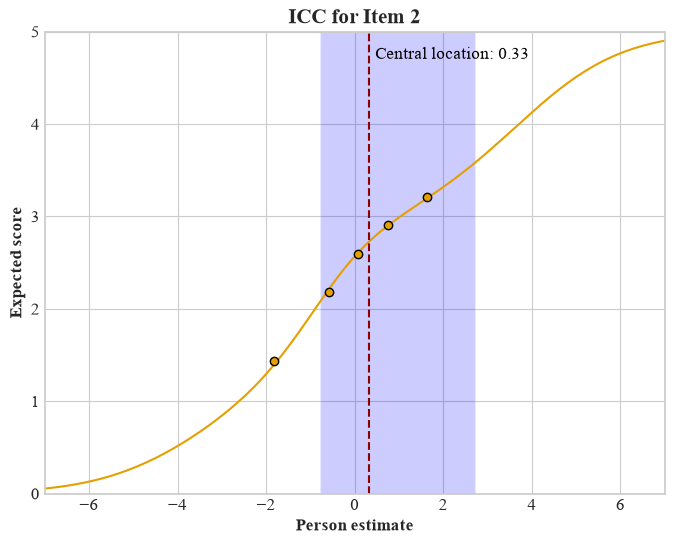

In [32]:
mfrm.icc_matrix('Item_2', title='ICC for Item 2', obs=True, central_location=True, cat_highlight=3, xmin=-7, xmax=7, filename='my_mfrm_matrix_icc')

Produce a set of category response curves for Item 2, with category 1 highlighted and the thresholds marked

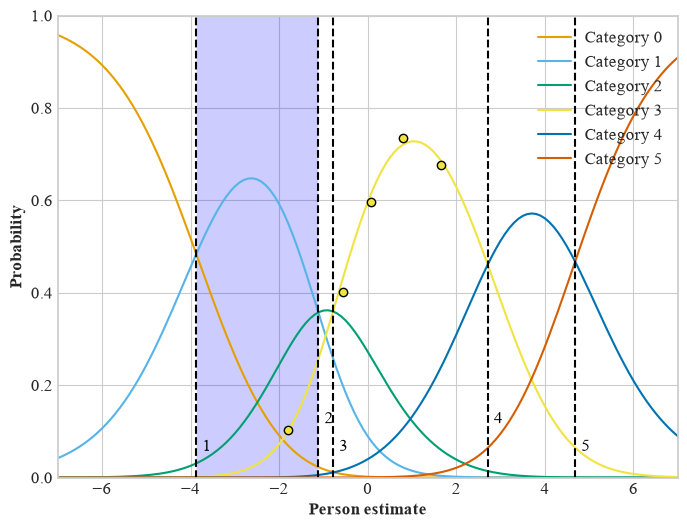

In [33]:
mfrm.crcs_matrix('Item_2', thresh_lines=True, obs=[3], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_matrix_crcs')

Produce a set of threshold characteristic curves for Item 2, with observed category means plotted for threshold 5, category 1 highlighted and the thresholds marked

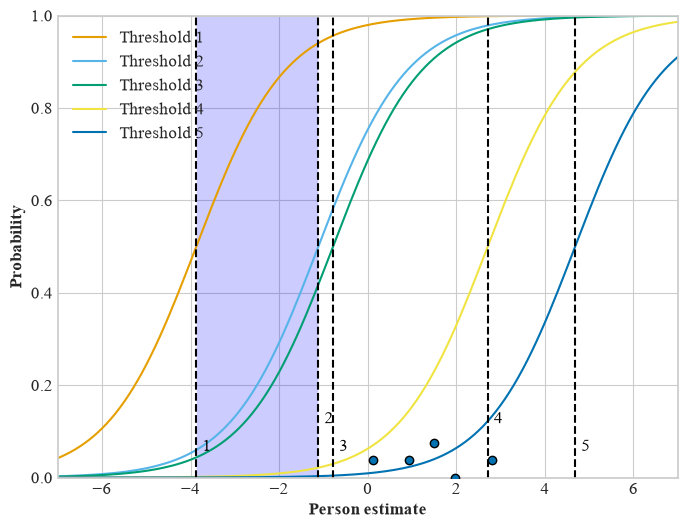

In [34]:
mfrm.threshold_ccs_matrix('Item_2', thresh_lines=True, obs=[5], cat_highlight=1, xmin=-7, xmax=7, filename='my_mfrm_matrix_threshold_ccs')

Produce an item information function curve for Item 2

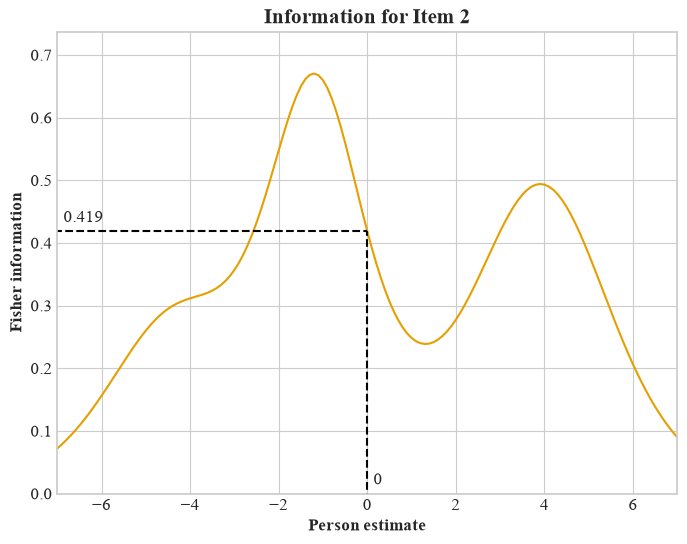

In [35]:
mfrm.iic_matrix('Item_2', title='Information for Item 2', point_info_lines=[0], point_info_labels=True,
                xmin=-7, xmax=7, filename='my_mfrm_matrix_iic')

Produce a test characteristic curve (test response function), with person locations corresponding to scores of 150 and 250 (aggregated across all raters) plotted.

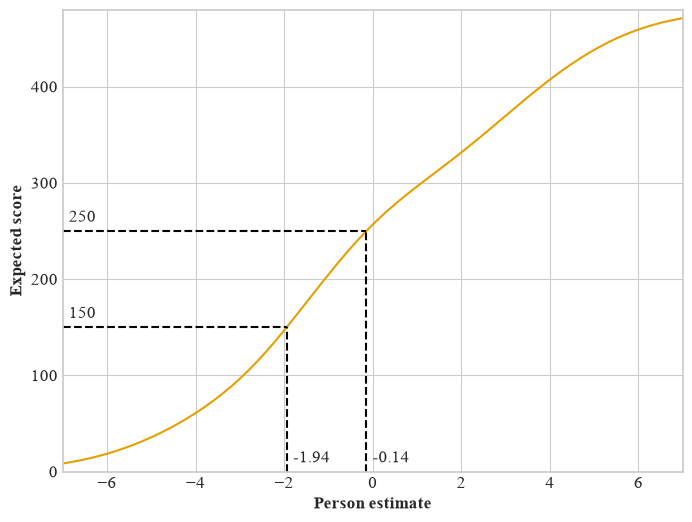

In [36]:
mfrm.tcc_matrix(score_lines=[150, 250], score_labels=True, xmin=-7, xmax=7, filename='my_mfrm_matrix_tcc')

Produce a test information curve

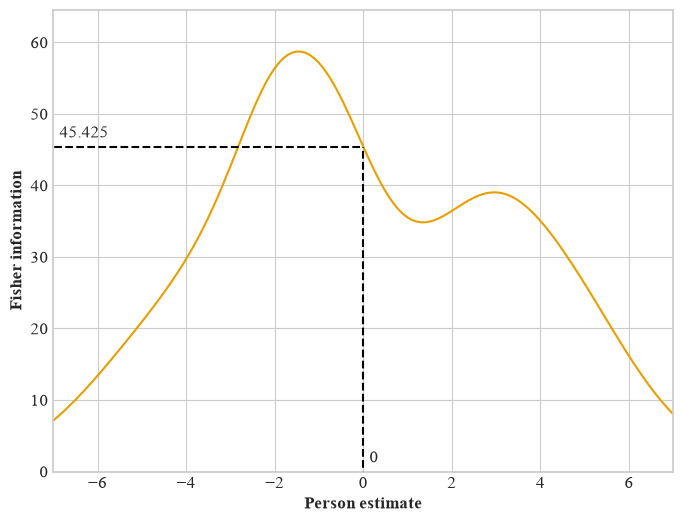

In [37]:
mfrm.test_info_matrix(point_info_lines=[0], point_info_labels=True, xmin=-7, xmax=7, filename='my_mfrm_matrix_test_info_curve')

Produce a test CSEM (conditional standard error of measurement) curve, with the CSEM corresponding to a person location of -3 plotted

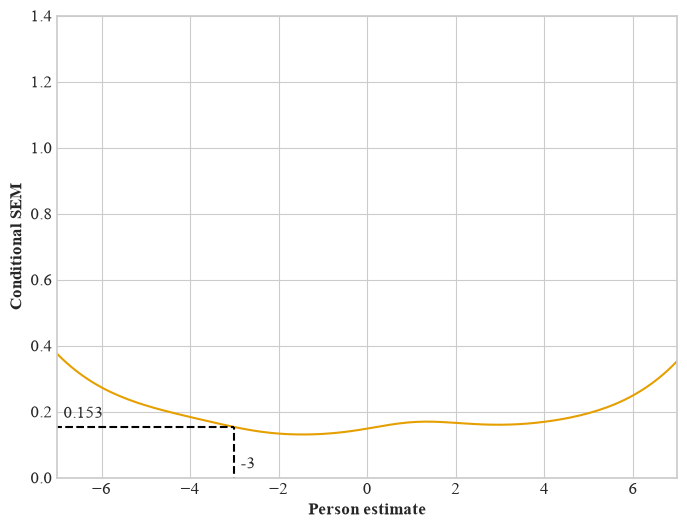

In [38]:
mfrm.test_csem_matrix(point_csem_lines=[-3], point_csem_labels=True, ymax=1.4, xmin=-7, xmax=7, filename='my_mfrm_matrix_csem_curve')

Produce a histogram of standardised residuals, with a normal distribution curve overlaid

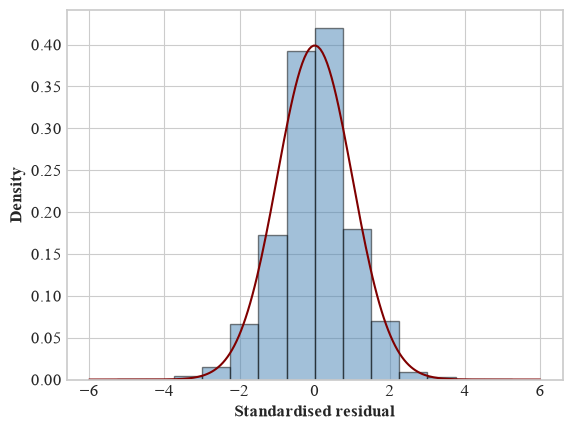

In [39]:
mfrm.std_residuals_plot_matrix(bin_width=0.6, normal=True, filename='my_mfrm_matrix_std_residuals_plot')

Now run an anchored analysis, anchoring to the mean severity of Raters 1-4 (e.g. a set of 'gold standard' raters).

In [40]:
%%time
anchors = ['Rater_1', 'Rater_2', 'Rater_3', 'Rater_4']
mfrm.calibrate_matrix_anchor(anchors)

CPU times: user 1.85 ms, sys: 290 μs, total: 2.14 ms
Wall time: 1.97 ms


Check the anchored item locations against the unanchored ones.

In [41]:
item_check = pd.DataFrame({'Unanchored': mfrm.items,
                           'Anchored': mfrm.anchor_items_matrix})
round(item_check, 3)

,Unanchored,Anchored
Item_1,0.954,1.004
Item_2,0.325,0.287
Item_3,-0.507,-0.659
Item_4,0.745,0.566
Item_5,0.974,1.118
Item_6,-0.210,-0.104
Item_7,-0.219,-0.055
Item_8,-0.931,-1.080
Item_9,-0.892,-0.841
Item_10,-0.194,-0.044


Check the anchored thresholds against the unanchored thresholds

In [42]:
threshold_check = pd.DataFrame({'Unanchored': mfrm.thresholds,
                                'Anchored': mfrm.anchor_thresholds_matrix})
round(threshold_check, 3)

,Unanchored,Anchored
1,-4.196,-4.180
2,-1.439,-1.396
3,-1.108,-1.108
4,2.384,2.435
5,4.359,4.249


Check the anchored marginal item severities against the unanchored ones - two dataframes

In [43]:
round(mfrm.marginal_raters_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.182,-0.110,-0.217,-0.308,-0.058,-0.223,0.188,-0.041,0.331,0.092,-0.505,0.044
Rater_2,0.372,0.104,-0.400,0.143,0.360,0.276,0.459,-0.201,-0.031,0.029,-0.176,0.046
Rater_3,-0.299,-0.349,-0.023,-0.426,0.044,0.309,-0.545,-0.615,-0.228,0.391,-0.019,-0.182
Rater_4,-0.080,0.176,0.006,-0.149,0.207,0.036,0.529,0.233,0.105,0.060,-0.045,0.181
Rater_5,0.162,0.199,0.543,0.210,-0.309,-0.322,-0.131,0.269,-0.107,-0.044,0.173,0.095
Rater_6,-0.649,-0.154,0.061,0.026,-0.020,-0.318,0.190,0.155,-0.197,-0.211,0.260,-0.261
Rater_7,0.330,0.383,-0.195,0.237,-0.224,-0.053,-0.303,-0.148,-0.137,-0.202,-0.142,-0.073
Rater_8,-0.019,-0.249,0.226,0.267,-0.001,0.295,-0.386,0.347,0.264,-0.116,0.453,0.151


In [44]:
round(mfrm.anchor_marginal_raters_items, 3)

,Item_1,Item_2,Item_3,Item_4,Item_5,Item_6,Item_7,Item_8,Item_9,Item_10,Item_11,Item_12
Rater_1,0.138,-0.065,-0.058,-0.123,-0.197,-0.322,0.030,0.115,0.287,-0.051,-0.319,0.022
Rater_2,0.328,0.149,-0.242,0.328,0.222,0.176,0.301,-0.045,-0.075,-0.114,0.010,0.024
Rater_3,-0.343,-0.304,0.135,-0.241,-0.094,0.210,-0.703,-0.459,-0.273,0.248,0.167,-0.204
Rater_4,-0.124,0.221,0.164,0.036,0.069,-0.064,0.372,0.389,0.061,-0.083,0.141,0.158
Rater_5,0.119,0.244,0.701,0.395,-0.447,-0.421,-0.289,0.425,-0.152,-0.187,0.359,0.073
Rater_6,-0.693,-0.110,0.220,0.211,-0.158,-0.417,0.033,0.311,-0.242,-0.354,0.446,-0.284
Rater_7,0.286,0.427,-0.037,0.422,-0.362,-0.152,-0.461,0.008,-0.181,-0.346,0.044,-0.095
Rater_8,-0.063,-0.204,0.385,0.452,-0.139,0.195,-0.544,0.503,0.219,-0.259,0.639,0.128


Check the anchored marginal threshold severities against the unanchored ones - two dataframes

In [45]:
round(mfrm.marginal_raters_thresholds, 3)

,1,2,3,4,5
Rater_1,-0.291,0.207,0.152,0.097,-0.164
Rater_2,0.249,-0.251,-0.140,-0.008,0.150
Rater_3,-0.210,0.292,0.046,-0.041,-0.087
Rater_4,0.315,-0.074,-0.059,0.154,-0.337
Rater_5,0.280,0.030,-0.188,-0.065,-0.057
Rater_6,0.016,-0.118,0.064,0.114,-0.077
Rater_7,-0.328,0.208,0.034,-0.072,0.158
Rater_8,-0.031,-0.295,0.091,-0.179,0.413


In [46]:
round(mfrm.anchor_marginal_raters_thresholds, 3)

,1,2,3,4,5
Rater_1,-0.307,0.163,0.152,0.046,-0.055
Rater_2,0.233,-0.294,-0.139,-0.059,0.259
Rater_3,-0.226,0.249,0.046,-0.092,0.023
Rater_4,0.300,-0.117,-0.059,0.104,-0.227
Rater_5,0.264,-0.014,-0.188,-0.115,0.052
Rater_6,0.000,-0.161,0.065,0.063,0.033
Rater_7,-0.344,0.164,0.035,-0.122,0.268
Rater_8,-0.046,-0.338,0.091,-0.229,0.523


Produce a Wright map (unanchored), showing the person location distribution alongside an item strip (one row per item, divided into its own category segments at each Rasch-Andrich threshold) and a rater panel, with mean/±1SD/±2SD reference marks for persons

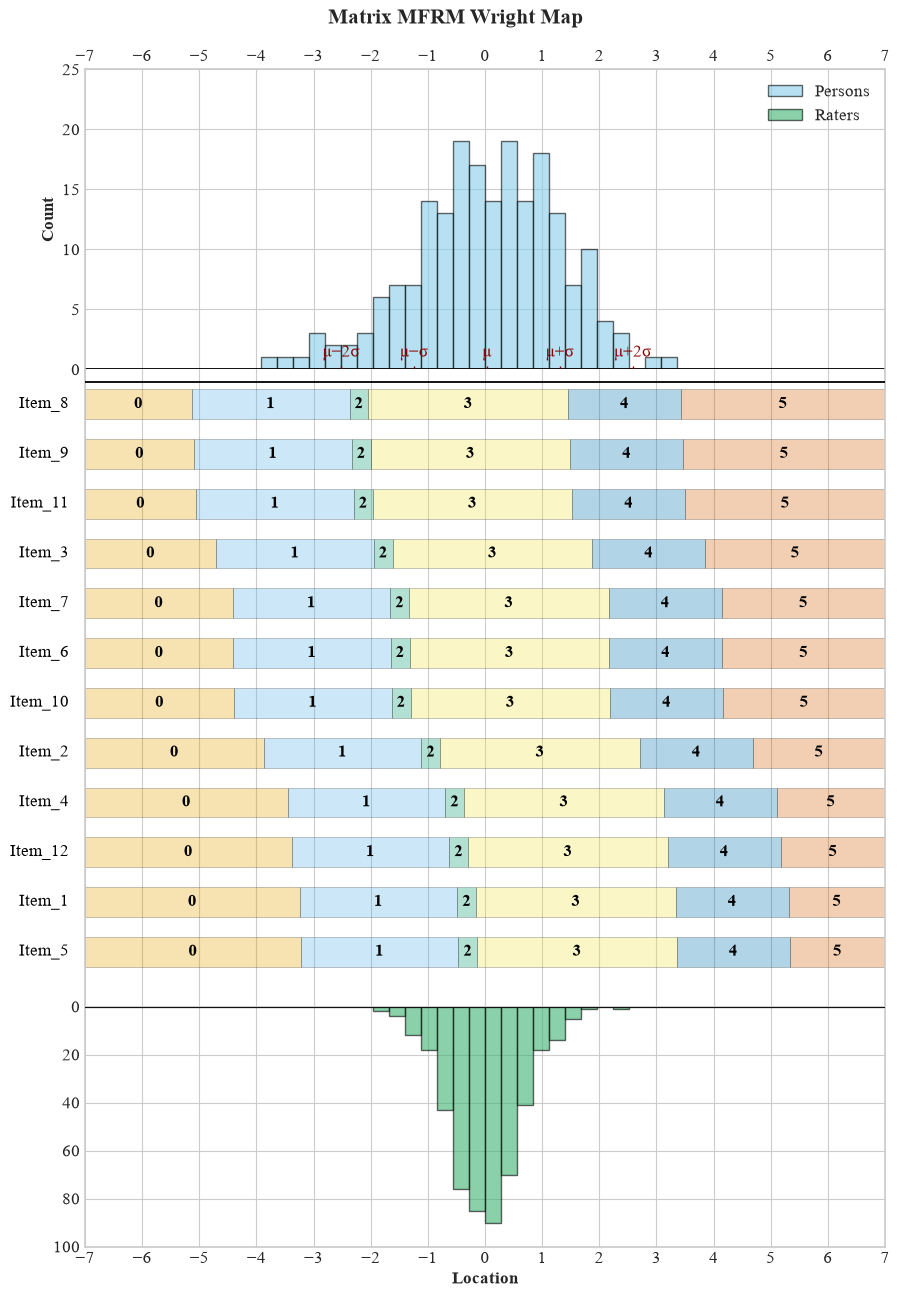

In [47]:
mfrm.wright_map_matrix(no_of_bins=50, item_strip=True, item_labels=True, facet_labels=False, distribution_markers=True,
                       facet_scaling=5, title='Matrix MFRM Wright Map', filename='my_mfrm_matrix_wright_map')